### Importing Packages

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Subset

import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm 

import scipy
from scipy.optimize import linear_sum_assignment

import copy

import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from functools import partial

from sklearn.cluster import KMeans

import string

### Seed

In [3]:
SEED = 46

np.random.seed(SEED)
torch.manual_seed(SEED)

### Importing Data

In [4]:
# Transform images to tensors
transform = transforms.ToTensor()

# Load training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

### Helper Functions

In [74]:
def filter_data(dataset, allowed_digits):

    labels = dataset.targets

    mask = torch.zeros_like(labels, dtype=torch.bool)

    for digit in allowed_digits:

        mask |= (labels == digit)

    indices = torch.where(mask)[0]

    filtered_dataset = Subset(dataset, indices)

    return filtered_dataset

In [90]:
def train_model(model, training_data_loader, training_digit_group, num_epochs,
                testing_data_loader,
                replay=False, replay_data_loader=None, replay_digit_group=None,
                penalty_function=None, λ=1,
               ):

    base_loss_function = nn.CrossEntropyLoss(reduction='mean')

    if penalty_function is None:
        penalty_function = null_penalty
        
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    cm_epoch_set = []
    pca_epoch_set = []
    scaler_epoch_set = []
    varexp_epoch_set = []
    kmeans_epoch_set = []
    loss_epoch_set = []

    epoch_counter = 0
    
    epoch_bar = tqdm(range(num_epochs))
    for epoch in epoch_bar:
        
        epoch_counter += 1

        ############################
        #### TRAINING
        ############################

        model.train()

        total_loss = 0.0

        batch_bar = tqdm(training_data_loader, desc=f"Epoch {epoch_counter}", leave=False, colour="green", miniters=20)
        for inputs, labels in batch_bar:


            if replay:
                for replay_digit in replay_digit_group:
                    replay_inputs, replay_labels = next(iter(replay_data_loader[replay_digit]))
                    inputs = torch.cat((inputs, replay_inputs), dim=0)
                    labels = torch.cat((labels, replay_labels), dim=0)
            

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = base_loss_function(outputs, labels) + λ*penalty_function(model, inputs)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        epoch_bar.set_postfix({"Total Loss": f"{total_loss:.4f}"})

        ############################
        #### VALIDATING
        ############################
            
        cm = get_cm(model, testing_data_loader)
        pca, scaler, varexp = get_pca(model, testing_data_loader, training_digit_group)
        kmeans = get_kmeans(model, testing_data_loader, seed=47)

        cm_epoch_set.append(cm)
        pca_epoch_set.append(pca)
        scaler_epoch_set.append(scaler)
        varexp_epoch_set.append(varexp)
        kmeans_epoch_set.append(kmeans)
        loss_epoch_set.append(total_loss)

    return copy.deepcopy(model), cm_epoch_set, pca_epoch_set, scaler_epoch_set, varexp_epoch_set, kmeans_epoch_set, loss_epoch_set

### get_cm(model, testing_data_loader)

Builds a confusion matrix for the given model using the testing data from testing_data_loader. Predictions are made by taken as the highest probability logit in the output of the mode:

$$prediction = \underset{i\in[0, 9]}{max}\hspace{0.1cm}l_{i}$$

$$\mathbf{N} = \underset{predicted \hspace{0.1cm}labels \hspace{0.1cm}\times\hspace{0.1cm} true \hspace{0.1cm}labels}{\begin{bmatrix} n_{1,1} & n_{1,2} & \cdots & n_{1, 10} \\
n_{2,1} & n_{2,2} & \cdots & n_{2, 10} \\ 
\vdots & \vdots & \ddots & \vdots \\
n_{10,1} & n_{10,2} & \cdots & n_{10, 10}\end{bmatrix}}$$

    Args:
        model                : neural network type; trained neural network
        testing_data_loader  : list type; list of DataLoaders of properly sorted MNIST testing images

    Returns:
        cm                   : array type; confusion matrix visualizing how the model predicts (rows) images of a specific true label (columns)

In [7]:
def get_cm(model, testing_data_loader):

    model.eval()

    with torch.no_grad():

        cm = np.zeros((10, 10))

        for true_label in range(10):

            for inputs, labels in testing_data_loader[true_label]:

                outputs = model(inputs)

                predicted_labels = torch.argmax(outputs, dim=1).numpy()

                np.add.at(cm, (predicted_labels, true_label), 1)

        return cm

### get_pca(model, testing_data_loader, digit_group)

Performs a principal component analysis (PCA) on the hidden-state representation of a group of digits digit_group within the neural network model. PCA is done by computing eigenvalue-eigenvector pairs of the Pearson-correlation matrix (covariance matrix is computed as feature covariances of feature-standardized data):

$$ \{\lambda_i, \hat{u}_i\}: \hspace{1cm} \mathbf{C}\hat{u}_i=\lambda_i\hat{u}_i$$

$$\underset{num \hspace{0.1cm}features\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{C}}=\frac{1}{num\hspace{0.1cm}samples-1}\underset{num\hspace{0.1cm}features\hspace{0.1cm}\times batch\hspace{0.1cm}size}{\mathbf{Z}^T}\hspace{0.3cm}\underset{batch \hspace{0.1cm}size\hspace{0.1cm}\times num \hspace{0.1cm}features}{\mathbf{Z}}$$

    Args:
        model: neural network type; the neural network whose hidden representation we are probing
        testing_data_loader: DataLoader type; the properly sorted testing data used to evaluate model
        digit_group: list type; list of digits we are probing for the hidden representation of

    Returns:
        pca: pca type; pca fit to the standardized hidden representation data
        scaler: ? type; scaler used to fit the pca 

In [8]:
def get_pca(model, testing_data_loader, digit_group):

    model.eval()

    with torch.no_grad():
    
        all_batches = []                                             # shape: null
 
        for digit in digit_group:
        
            for inputs, labels in testing_data_loader[digit]:
            
                hidden_outputs = model.hidden(inputs).numpy()        # shape: (batch_size, hidden_size)
       
                all_batches.append(hidden_outputs)                   
 
        data = np.concatenate(all_batches, axis=0)                   # shape: (num_batchs X batch_size, hidden_size)
 
        scaler = StandardScaler()
        standardized_data = scaler.fit_transform(data)
 
        pca = PCA()
        pca.fit(standardized_data)                                   # shape: (hidden_size, hidden_size) (since hidden_size < num_batchs X batch_size)

        varexp = pca.explained_variance_ratio_.cumsum()
 
        return pca, scaler, varexp

### get_kmeans(model, testing_data_loader, seed)

Returns a k-means classification confusion matrix of model's hidden representation of all digits using images from testing_data_loader. 

$$\mathbf{N} = \underset{predicted \hspace{0.1cm}class \hspace{0.1cm}\times\hspace{0.1cm} true \hspace{0.1cm}labels}{\begin{bmatrix} n_{1,1} & n_{A,2} & \cdots & n_{A, 10} \\
n_{B,1} & n_{B,2} & \cdots & n_{B, 10} \\ 
\vdots & \vdots & \ddots & \vdots \\
n_{J,1} & n_{J,2} & \cdots & n_{J, 10}\end{bmatrix}}$$

    Args: 
        model: neural network type; the model the hidden representation k-means are done on
        testing_data_loader: list type; list of DataLoader types of MNIST testing images sorted by digit
        seed                  : int type; seed number for repeatable stochastic results

    Returns:
        cm: array type; confusion matrix of predicted classifications vs. their true label

In [9]:
def get_kmeans(model, testing_data_loader, seed):

    model.eval()

    with torch.no_grad():

        all_hidden_outputs = []
        all_labels = []

        for digit in range(10):

            for inputs, labels in testing_data_loader[digit]:

                hidden_outputs = model.hidden(inputs)

                all_hidden_outputs.append(hidden_outputs.numpy())
                all_labels.append(labels.squeeze().numpy())

        data = np.concatenate(all_hidden_outputs, axis=0)
        true_labels = np.concatenate(all_labels, axis=0)

        kmeans = KMeans(n_clusters=10, random_state=seed)
        kmeans.fit(data)
        predicted_labels = kmeans.labels_

        cm = np.zeros((10, 10))

        np.add.at(cm, (predicted_labels, true_labels), 1)

    return cm

### get_am(cm_set, training_digit_groups)

In [10]:
def get_am(cm_set, training_digit_groups):

    num_groups = len(cm_set)

    am = np.zeros((num_groups, num_groups))

    for j in range(num_groups):

        for i in range(num_groups):

            num_correct = cm_set[j][-1][training_digit_groups[i], training_digit_groups[i]].sum()
            num_total = cm_set[j][-1][:, training_digit_groups[i]].sum()

            am[i, j] = num_correct/num_total

    return am
            

### null_penalty(model inputs)

Null penalty, always returns tensor(0.0).

    Args:
        model                      : Neural Network type; neural network being trained (VACUOUS PASS)
        inputs                     : tensor type; input data the neural network is being trained on (VACUOUS PASS)

    Returns:
        penalty                    : float type; penalty (with auto-grad) to be added to loss function in neural network training (always tensor(0.0))

In [11]:
def null_penalty(model, inputs):
    return torch.tensor(0.0)

### pca_drift_penalty(model, inputs, old_pca_components, norm)

This function penalizes how much of the current hidden representation of the inputs lies within the span of some subset of the old principal components. The penalty is computed according to the following rule:


$$\underset{(batch \hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{h}_i} = \underset{(batch \hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{H}_i}\hspace{0.3cm}\underset{(hidden\hspace{0.1cm} size \hspace{0.1cm}\times\hspace{0.1cm} pca\hspace{0.1cm} size)}{\mathbf{P^T}}\hspace{0.3cm}\underset{(pca\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{P}}$$

$$\underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{R}_i} = \underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{H}_i}-\underset{(batch\hspace{0.1cm} size\hspace{0.1cm}\times\hspace{0.1cm} hidden\hspace{0.1cm} size)}{\mathbf{h}_i}$$

$$\underset{1\times 1}{penalty} = \frac{1}{batch\hspace{0.1cm}size\hspace{0.1cm}\times\hspace{0.1cm}
hidden\hspace{0.1cm}size}\sum_{n=1}^{batch\hspace{0.1cm} size}\sum_{m=1}^{hidden\hspace{0.1cm} size}R_{nm}^2$$

    Args:
        model                      : Neural Network type; neural network being trained
        inputs                     : tensor type; input data the neural network is being trained on
        old_pca_components         : array type; subspace the hidden representation will be projected onto and reconstructed out of
        norm                       : int type; Euclidean norm to use in the penalty

    Returns:
        penalty                    : float type; penalty (with auto-grad) to be added to loss function in neural network training
        

In [12]:
def pca_drift_penalty(model, inputs, old_pca_components, old_scaler, norm):

    if old_pca_components is None:
        return torch.tensor(0.0)
    
    V = torch.tensor(old_pca_components, dtype=torch.float32)            # shape: (pca_size, hidden_size)
    mean = torch.tensor(old_scaler.mean_, dtype=torch.float32)           # shape: (hidden_size,)
    std = torch.tensor(old_scaler.scale_, dtype=torch.float32)           # shape: (hidden_size,)

    hidden_outputs = model.hidden(inputs)              # shape: (batch_size, hidden_size)
    scaled_hidden_outputs = (hidden_outputs-mean)/std

    projections   = scaled_hidden_outputs @ V.T               # shape: (batch_size, hidden_size) X (hidden_size, pca_size) = (batch_size, pca_size)
    reconstructions = projections @ V                  # shape: (batch_size, pca_size) X (pca_size, hidden_size) = (batch_size, hidden_size)

    residual = scaled_hidden_outputs - reconstructions        # shape: (batch, hidden_size)
    penalty  = residual.abs().pow(norm).sum(dim=1).mean(dim=0)              # shape: ()

    return penalty

### corrs_penalty(model, inputs, cluster_labels, cluster_corrs, old_model)

This function penalizes how much the weights of neurons drift from their original values, weighted by the correlation of the neurons' parent cluster.


$$penalty = \sum_{clusters}\rho_{C, old}\sum_{neurons}(||(\vec{W}_{n, new}\otimes b_{n, new})-(\vec{W}_{n, old}\otimes b_{n, old})||^2$$


    Args:
        model                      : Neural Network type; neural network being trained
        inputs                     : tensor type; input data the neural network is being trained on (VACUOUS PASS)
        cluster_labels             : array type; arary mapping neurons to a parent cluster
        cluster_corrs              : array type; array type assigning a correlative importance to each parent cluster
        old_model                  : Neural Network type; old neural network used to constrain further training
        norm                       : int type; Euclidean norm to use in the penalty

    Returns:
        penalty                    : float type; penalty (with auto-grad) to be added to loss function in neural network training

In [13]:
def corrs_penalty(model, inputs, cluster_labels, cluster_corrs, old_model, norm, corr_cutoff):

    weights = torch.tensor(cluster_corrs[cluster_labels-1], dtype=torch.float32)                             # shape: (total_num_neurons, )
    mask = torch.where(weights>corr_cutoff, weights, 0.0)

    penalty = torch.tensor(0.0)                                                                              # shape: ()

    layer_pairs = [(model.layer1, old_model.layer1),
                  (model.layer2, old_model.layer2),
                  (model.layer3, old_model.layer3)
                  ]

    neuron_offset = 0

    for layer, old_layer in layer_pairs:

        num_neurons = layer.weight.shape[0]

        params = torch.cat((layer.weight, layer.bias.unsqueeze(1)), dim=1)                                  # shape: (num_neurons, num_weights+1)
        old_params = torch.cat((old_layer.weight.detach(), old_layer.bias.detach().unsqueeze(1)), dim=1)    # shape: (num_neurons, num_weights+1)

        drift = (params-old_params).abs().pow(norm).sum(dim=1)                                                       # shape: (num_neurons,)

        penalty = penalty + (mask[neuron_offset:neuron_offset+num_neurons]*drift).sum()                  # shape: ()

        neuron_offset = neuron_offset + num_neurons

    return penalty

In [14]:
def logit_penalty(model, inputs, old_model, old_representatives, norm):
    
    old_model.eval()

    weights = model.layer3.weight                                # shape: (10, 64)
    old_weights = old_model.layer3.weight.detach()               # shape: (10, 64)

    drift = (weights-old_weights) @ old_representatives.T           # shape: (10, 64) X (64, 3)

    penalty = drift.abs().pow(norm).sum()

    return penalty

In [15]:
def get_representatives(model, testing_data_loader, digit_group):

    model.eval()

    with torch.no_grad():

        all_representatives = []

        for digit in digit_group:

            all_batches = []

            for inputs, labels in testing_data_loader[digit]:

                hidden_outputs = model.hidden(inputs).numpy()                                   # shape: (batch_size, 64)

                all_batches.append(hidden_outputs)

            all_batches = np.concatenate(all_batches, axis=0)                            # shape: (num_batches X batch_size, 64)

            representative = all_batches.mean(axis=0, keepdims=True)                                    # shape: (64, )

            all_representatives.append(representative)

        all_representatives = np.concatenate(all_representatives, axis=0)            # shape: (3, 64)

        return all_representatives                                                      # shape: (3, 64)
         

### monte_carlo_cgm(dim_subspace, dim_space, n_samples=100_000, seed=42)

Monte Carlo estimate (N = n_samples, from seed) of the mean and standard deviation of the cross-Gram-matrices two randomly sampled dim_subspace-dimensional orthonormal bases $\mathcal{U}, \mathcal{V}\in\mathbb{R}^{dim\hspace{0.1cm}space \hspace{0.1cm}\times\hspace{0.1cm} dim \hspace{0.1cm} subspace}$. The n_samples pairs of subspaces are drawn as a dim_space by dim_subspace array of dim_subspace samples from the dim_space dimensional standard normal distribution, $\mathcal{N}_{dim\hspace{0.1cm}space}(0, 1)$ and orthonormalized. 

Analytical Expressions (dim_subspace=1):

$$\mu_{|\hat{u}\cdot\hat{v}|} = \frac{\Gamma\left(\frac{d}{2}\right)}{\sqrt{\pi}\Gamma\left(\frac{d+1}{2}\right)}\overset{d=64}{\approx}0.100$$

$$\sigma_{|\hat{u}\cdot\hat{v}|} = \sqrt{\frac{1}{d}-\mu_{|\hat{u}\cdot\hat{v}|}^2}\overset{d=64}{\approx}0.075$$

    Args:
        dim_subspace          : int type; dimensionality of subspaces being drawn
        dim_space             : int type; dimensionality of the overall space embedding the subspaces
        n_samples             : int type; number of sample drawn for the Monte Carlo approximation
        seed                  : int type; seed number for repeatable stochastic results

    Returns:
        μ                     : float type; sample mean computed by Monte Carlo
        σ                     : float type; sample standard deviation computed by Monte Carlo

In [16]:
def monte_carlo_cgm(dim_subspace, dim_space, n_samples=100_000, seed=42):

    rng = np.random.default_rng(seed)
 
    U = rng.standard_normal((n_samples, dim_space, dim_subspace))          # shape: (n_samples, dim_space, dim_subspace)
    V = rng.standard_normal((n_samples, dim_space, dim_subspace))          # shape: (n_samples, dim_space, dim_subspace)

    U, _ = np.linalg.qr(U)                                                   # shape: (n_samples, dim_space, dim_subspace)
    V, _ = np.linalg.qr(V)                                                   # shape: (n_samples, dim_space, dim_subspace)

    cgm = np.abs(np.einsum("ndi, ndj -> nij", U, V))                             # shape: (n_samples, dim_subspace, dim_subspace)

 
    μ = np.mean(cgm)                      # shape: ()
    σ = np.std(cgm)                       # shape: ()  
 
    return μ, σ

In [17]:
def get_hungarian(benefit_matrix):

    tol = 1e-10

    # Normalize benefit matrix to [0,1]
    benefit_matrix = np.clip(benefit_matrix, 0, 1)

    # Convert trace maximization into trace minimization
    cost_matrix = 1 - benefit_matrix

    n, m = cost_matrix.shape

    cost_matrix -= cost_matrix.min(axis=0, keepdims=True)
    cost_matrix -= cost_matrix.min(axis=1, keepdims=True)

    # Starring 0s
    stars_matrix = np.zeros_like(cost_matrix, dtype=bool)

    row_has_star = np.zeros(n, dtype=bool)
    col_has_star = np.zeros(m, dtype=bool)

    # Choosing sequentially unclaimed rows or columns with 0s
    for i in range(n):

        for j in range(m):

            if cost_matrix[i,j] <= tol and not row_has_star[i] and not col_has_star[j]:

                stars_matrix[i,j] = 1
                row_has_star[i] = 1
                col_has_star[j] = 1

    # Main loop

    # Outer Loop
    while True:

        row_covered = np.zeros(n, dtype=bool)
        col_covered = np.zeros(m, dtype=bool)
        primes_matrix = np.zeros_like(cost_matrix, dtype=bool)

        for j in range(m):

            for i in range(n):

                col_covered[j] |= stars_matrix[i][j] 

        if col_covered == np.ones(m, dtype=bool):

            break 

        # Inner Loop
        while True:

            for r in range(n):

                for c in range(m):

                    if cost_matrix[r,c] < tol and not row_covered[r] and not col_covered[c]:

                        primes_matrix[r, c] = 1

                        # Outcome B
                        for c_star in range(m):

                            if stars_matrix[r, c_star]:

                                row_covered[r] = 1
                                col_covered[c_star] = 0
                                break
                                
                            




                    
            

In [18]:
def get_clusters(model, testing_data_loader, digit_group, corr_threshold):

    #####################################
    ### ALL ACTIVATIONS
    #####################################

    model.eval()
    with torch.no_grad():

        all_a1, all_a2, all_a3, all_labels = [], [], [], []
    
        for digit in digit_group:
            for inputs, labels in testing_data_loader[digit]:

                a1 = model.forward1(inputs).numpy()             # shape: (batch_size, num_neurons_1)
                a2 = model.forward2(inputs).numpy()             # shape: (batch_size, num_neurons_2) 
                a3 = model.forward3(inputs).numpy()             # shape: (batch_size, num_neurons_3)
                labels = labels.numpy()

                all_a1.append(a1)                               # shape: (num_batches, batch_size, num_neurons_1)
                all_a2.append(a2)                               # shape: (num_batches, batch_size, num_neurons_2)
                all_a3.append(a3)                               # shape: (num_batches, batch_size, num_neurons_3)
                all_labels.append(labels)


        all_a1 = np.concatenate(all_a1, axis=0)                 # shape: (num_batches X batch_size, num_neurons_1)
        all_a2 = np.concatenate(all_a2, axis=0)                 # shape: (num_batches X batch_size, num_neurons_2)
        all_a3 = np.concatenate(all_a3, axis=0)                 # shape: (num_batches X batch_size, num_neurons_3)
        all_labels = np.concatenate(all_labels, axis=0)

        all_activations = np.concatenate((all_a1, all_a2, all_a3), axis=1) # shape: (num_batches X batch_size, num_neurons_tot)

    #####################################
    ### GET CORRELATIONS
    #####################################

    corr_matrix = np.corrcoef(all_activations.T)                # shape: (num_neurons_tot, num_neurons_tot)
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, copy=False)         # shape: (num_neurons_tot, num_neurons_tot)

    #####################################
    ### CLUSTERING
    #####################################

    dist = 1 - np.clip(np.abs(corr_matrix), 0, 1)                          # shape: (num_neurons_tot, num_neurons_tot)
    np.fill_diagonal(dist, 0)                                              # shape: (num_neurons_tot, num_neurons_tot)
    condensed = squareform(dist, checks=False)                             # shape: (num_neurons_tot X (num_neurons_tot-1)/2, )
    Z = linkage(condensed, method="average")
    cluster_labels = fcluster(Z, t=1-corr_threshold, criterion="distance")

    #####################################
    ### DIGIT CORRELATIONS
    #####################################

    corrs_cluster_set = []                                                                # shape: (num_clusters)
    num_clusters = np.max(cluster_labels)
    
    for cluster_id in range(1, num_clusters+1):
        corrs_digit_set = []                                                               # shape: (num_digits, )
        cluster_mask_bool = cluster_labels == cluster_id                                   # shape: (num_neurons_tot, ) bool
        coarse_cluster_activations = all_activations[:, cluster_mask_bool].mean(axis=1)    # shape: (num_samples, )
        
        for digit in digit_group:
            binary_label_mask = np.where(all_labels==digit, 1, 0)                          # shape: (num_samples, ) binary
            corr = np.corrcoef(coarse_cluster_activations, binary_label_mask)[0, 1]        # shape: ()
            corr = np.nan_to_num(corr, nan=0.0)
            corrs_digit_set.append(corr)

        corrs_cluster_set.append( np.max( np.abs(corrs_digit_set) ) )

    corrs_cluster_set = np.array(corrs_cluster_set)

    return cluster_labels, corrs_cluster_set, Z                                                     # shape: (num_clusters)

In [19]:
def make_colormap(vmin, vmax, neutral_low, neutral_high, mid1, mid2):
    
    def p(z):
        return (z - vmin) / (vmax - vmin)

    cmap = LinearSegmentedColormap.from_list(
        'cgm_zones',
        [
            (p(vmin),         '#2166AC'),
            (p(neutral_low),  '#D1E5F0'),
            (p(neutral_low),  '#B0B0B0'),
            (p(neutral_high), '#B0B0B0'),
            (p(neutral_high), '#FFFFCC'),
            (p(mid1),         '#FD8D3C'),
            (p(mid2),         '#D7191C'),
            (p(vmax),         '#67000D'),
        ],
        N=512
    )
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    return cmap, norm

In [20]:
def plot_cms(cm_set, normalize=True):

    num_groups, num_epochs = len(cm_set), len(cm_set[0])

    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(6 * num_groups, 7 * num_epochs)
                            )
    
    axes = np.array(axes).reshape(num_epochs, num_groups)

    for m in range(num_groups):          
        for n in range(num_epochs):     

            ax = axes[n, m]
            cm = cm_set[m][n]

            if normalize:
                cm = cm / cm.sum(axis=0, keepdims=True)
                im = ax.imshow(cm, cmap='Blues')
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        ax.text(
                            j, i,
                            f"{cm[i, j]:.0%}",
                            ha='center',
                            va='center',
                            color='black',
                            fontsize=8
                            )

            else: 
                im = ax.imshow(cm, cmap='Blues')
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        ax.text(
                            j, i,
                            str(int(cm[i, j])),
                            ha='center',
                            va='center',
                            color='black',
                            fontsize=8
                            )

            ax.set_title(f"Training Group {m+1}, Epoch {n+1}")

            ax.set_xlabel("True Label")
            ax.set_ylabel("Predicted Label")

            ax.set_xticks(range(10))
            ax.set_yticks(range(10))

    # One shared colorbar (important)
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)

    plt.show()

    return

In [64]:
def plot_cgms(pca_set, μ_cgm, σ_cgm, window=(-1, -1), diagonalize=False):

    ###########################################
    #### MAKING CGMS
    ###########################################
    
    num_groups, num_epochs = len(pca_set), len(pca_set[0])
    
    lower, upper = window
    
    if lower == -1:
        lower = 0
        
    if upper == -1:
        upper = flattened_pca_set[0].components_.shape[0]
            

    cgm_group_set = {}

    for i in range(num_groups):

        cgm_epoch_set = {}
        
        for j in range(num_epochs):

            pca_components_A = pca_set[i][j].components_
            pca_components_B = pca_set[0][num_epochs-1].components_

            cgm = np.abs(pca_components_A @ pca_components_B.T)
            w_cgm = cgm[lower:upper, lower:upper]

            if diagonalize:

                cost = - w_cgm
                rows, cols = linear_sum_assignment(cost)
                dw_cgm = w_cgm[:, cols]
                cgm_epoch_set[j] = dw_cgm

            else:

                cgm_epoch_set[j] = w_cgm

        cgm_group_set[i] = cgm_epoch_set

    
    ###########################################
    #### MAKING PLOTS
    ###########################################

    cgm_cmap, cgm_norm = make_colormap(
                                            vmin=μ_cgm-2*σ_cgm,
                                            vmax=μ_cgm+13*σ_cgm,
                                            neutral_low=μ_cgm-2*σ_cgm,     
                                            neutral_high=μ_cgm+4*σ_cgm,
                                            mid1 = μ_cgm+6*σ_cgm,
                                            mid2 = μ_cgm+9*σ_cgm
                                        )
 
    CGM_TICKS  = [0.00, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
    CGM_LABELS = ['0.00\n(min)', '0.10\n(~mean)', '0.20', '0.30', '0.40\n(~threshold)', '0.50', '0.60', '0.70', '0.80', '0.90', '1.00\n(max)']
    
    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(6 * num_groups, 7 * num_epochs)
                            )

    axes = np.array(axes).reshape(num_epochs, num_groups)

    for i in range(num_groups):
        for j in range(num_epochs):

            ax = axes[j, i]
            cgm = cgm_group_set[i][j]
            im = ax.imshow(cgm, cmap=cgm_cmap, norm=cgm_norm)

            for n in range(cgm.shape[0]):
                for m in range(cgm.shape[1]):
                    if cgm[n, m] > μ_cgm+4*σ_cgm:
                        ax.text(
                                    m, n,
                                    f"{cgm[n, m]:.0%}",
                                    ha='center',
                                    va='center',
                                    color='black',
                                    fontsize=8
                                    )
                    else:
                        continue

        ax.set_title(f"Training Group {i+1}, Epoch {j+1} \n on Training Group {0+1}, Epoch {num_epochs}")

        ax.set_xlabel(f"PCs of Training Group {i+1}, Epoch {j+1}")
        ax.set_ylabel(f"PCs of Training Group {0+1}, Epoch {num_epochs}")

    cbar = fig.colorbar(im, ax=axes, ticks=CGM_TICKS, fraction=0.02, pad=0.04)
    cbar.ax.set_yticklabels(CGM_LABELS)
    cbar.set_label("PC Cosine Distance Overlap", rotation=270, labelpad=20)

    plt.show()
    
    return

In [22]:
def plot_varexp(varexp_set):

    num_rows, num_cols = len(varexp_set[0]), len(varexp_set)

    fig, axes = plt.subplots(nrows=num_rows,
                            ncols=num_cols,
                            figsize=(5*num_cols, 4*num_rows)
                            )

    axes = np.array(axes).reshape(num_rows, num_cols)

    for i in range(num_rows):
        for j in range(num_cols):

            ax = axes[i, j]

            Y = varexp_set[j][i]
            X = [i+1 for i in range(len(Y))]

            ax.plot(X, Y)

            ax.set_title(f"Fraction Variance Explained | Group {j+1}, Epoch {i+1}")
            ax.set_xlabel(f"Number of PCA Components")
            ax.set_ylabel(f"Cumulative Variance Explained")
            ax.set_yticks([i*0.10 for i in range(11)])
            ax.grid(True)

    fig.tight_layout()
    plt.show()

    return

In [23]:
def plot_kmeans(kmeans_set, diagonalize=False, normalize=True):

    num_groups, num_epochs = len(kmeans_set), len(kmeans_set[0])

    fig, axes = plt.subplots(
                            nrows=num_epochs,
                            ncols=num_groups,
                            figsize=(4 * num_groups, 5 * num_epochs)
                            )
    
    axes = np.array(axes).reshape(num_epochs, num_groups)

    for m in range(num_groups):          
        for n in range(num_epochs):     

            ax = axes[n, m]
            cm = kmeans_set[m][n]

            if diagonalize:
                cost = np.max(cm) - cm
                rows, cols = linear_sum_assignment(cost)
                cm = cm[:, cols]

            if normalize:
                cm = cm / cm.sum(axis=0, keepdims=True)
                im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        ax.text(
                            j, i,
                            f"{cm[i, j]:.0%}",
                            ha='center',
                            va='center',
                            color='black',
                            fontsize=8
                            )

            else: 
                im = ax.imshow(cm, cmap='Blues')
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        ax.text(
                            j, i,
                            str(int(cm[i, j])),
                            ha='center',
                            va='center',
                            color='black',
                            fontsize=8
                            )

            ax.set_title(f"Training Group {m+1}, Epoch {n+1}")

            ax.set_xlabel("True Label")
            ax.set_ylabel("Predicted Class")

            ax.set_xticks(range(10))
            ax.set_yticks(range(10))
            ax.set_yticklabels(list(string.ascii_uppercase[:10]))
            

    # One shared colorbar (important)
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)

    plt.show()

    return

In [24]:
def plot_loss(loss_set):

    num_groups, num_epochs = len(loss_set), len(loss_set[0])

    plt.figure(figsize=(7, 4))
    plt.title("Training Group Average Training Loss Curves ")
    plt.xlabel("Epoch")
    plt.ylabel("Average Training Loss")
    plt.xticks(np.arange(num_epochs)+1)
    plt.grid(True)

    for i in range(num_groups):

        x = np.arange(num_epochs)+1
        y = np.array(loss_set[i])
        plt.plot(x, y, marker="s", label=f"Group {i+1}")

    plt.legend()

    return
    

In [25]:
def plot_am(am):

    plt.figure(figsize=(7, 7))
    plt.imshow(am, cmap='Blues')
    n, m = am.shape
    for i in range(n):
        for j in range(m):
            plt.text(j, i, f"{am[i,j]:.0%}",
                   ha='center',
                   va='center',
                    color='black',
                   fontsize=8)

    plt.title('Accuracy Matrix')
    plt.xlabel('Training Group')
    plt.ylabel('Task')
    plt.xticks(np.arange(m), [f"{j+1}" for j in range(m)])
    plt.yticks(np.arange(n), [f"{i+1}" for i in range(n)])
    plt.colorbar(fraction=0.02, pad=0.02)
    plt.show()
    return

In [26]:
def plot_clusters(linkage_set):

    num_rows = 1
    num_cols = len(linkage_set)
    
    fig, axes = plt.subplots(nrows=num_rows,
                           ncols=num_cols,
                           figsize=(7*num_cols, 4*num_rows)
                          )

    axes = np.array(axes).reshape(num_rows, num_cols)

    for i in range(num_rows):
        for j in range(num_cols):

            ax = axes[i, j]
            Z = linkage_set[j]

            cluster_threshs = np.array([0.10*i for i in range(11)])
            cluster_info = [ np.unique(fcluster(Z, t=1-t, criterion="distance"), return_counts=True) for t in cluster_threshs ]
            cluster_counts = np.array([ max(ids) for ids, sizes in cluster_info ])
            cluster_sizes = [ f"{max(sizes)}" for ids, sizes in cluster_info ]
    
            bars = ax.bar(cluster_threshs, cluster_counts, width=0.08, edgecolor='black')
            ax.bar_label(bars, labels=cluster_sizes, padding=3, fontsize=8)
            ax.set_title('Number of Clusters vs. Correlation Threshold')
            ax.set_xlabel('Correlation Threshold')
            ax.set_ylabel('Number of Clusters')
            ax.set_xticks(cluster_threshs)
            ax.set_ylim(0, cluster_counts.max()*1.12)
            ax.grid(True, axis="y", alpha=0.4)

    plt.show()
    
    return

In [27]:
def get_opt_images(model, cluster_labels, num_steps=500, ε=0.1):

    model.eval()

    opt_images = []

    num_clusters = np.max(cluster_labels)

    for i in tqdm(range(1, num_clusters+1)):

        cluster_i = np.where(cluster_labels==i)[0]

        image_i = torch.randn((1, 28, 28), requires_grad=True)

        optimizer = optim.Adam([image_i], lr=ε)

        for step in range(num_steps):
        
            optimizer.zero_grad()

            benefit = model.cluster_activation(image_i, cluster_i)

            loss = -benefit.mean()

            loss.backward()
            optimizer.step()

        opt_image_i = image_i.detach().squeeze().clamp(0, 1)

        opt_images.append(opt_image_i)

    return opt_images

In [28]:
def plot_opt_images(opt_images):

    num_plots = len(opt_images)

    num_cols = 4

    if num_plots%num_cols == 0:
        num_rows = num_plots//num_cols
    else:
        num_rows = num_plots//num_cols + 1


    fig, axes = plt.subplots(nrows = num_rows, ncols=num_cols, figsize=(6*num_cols, 6*num_rows))

    axes = np.array(axes).reshape(num_rows, num_cols)

    for n in range(num_rows):
        for m in range(num_cols):

            ax = axes[n, m]

            if num_cols*n+m >= num_plots:
                ax.axis("off")
                continue

            image = opt_images[num_cols*n+m]

            im = ax.imshow(image, cmap="gray")

            ax.set_title(f"Cluster {num_cols*n+m+1} Optimal Image")

    plt.show()

### Training Data

In [29]:
training_digit_groups = [[0, 1, 2], [3, 4, 5]]

In [30]:
training_groups = []

In [31]:
num_training_groups= len(training_digit_groups)

for i in range(num_training_groups):

    training_digit_group = training_digit_groups[i]

    X = filter_data(train_dataset, training_digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    training_groups.append(Y)

### Testing Data

In [32]:
testing_digit_groups = [[i] for i in range(10)]

In [33]:
testing_groups = []

In [34]:
num_testing_groups = len(testing_digit_groups)

for i in range(num_testing_groups):

    testing_digit_group = testing_digit_groups[i]

    X = filter_data(test_dataset, testing_digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    testing_groups.append(Y)

### Replay Data

In [78]:
replay_digit_groups = [[i] for i in range(10)]

In [79]:
replay_groups = []

In [88]:
num_replay_groups = len(replay_digit_groups)

for i in range(num_replay_groups):

    replay_digit_group = replay_digit_groups[i]

    X = filter_data(train_dataset, replay_digit_group)

    Y = DataLoader(X, batch_size=5, shuffle=True)

    replay_groups.append(Y)

### Training/Testing/Replay Data Info

In [81]:
for training_inputs, training_labels in training_groups[0]:
    print(training_inputs.shape, training_labels.shape)
    print(training_labels)
    break

for testing_inputs, testing_labels in testing_groups[0]:
    print(testing_inputs.shape, testing_labels.shape)
    print(testing_labels)
    break

for replay_inputs, replay_labels in replay_groups[0]:
    print(replay_inputs.shape, replay_labels.shape)
    print(replay_labels)
    break

torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([1, 2, 0, 1, 0, 0, 1, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1, 2, 0, 0, 0, 1, 0, 2,
        0, 2, 0, 0, 1, 1, 1, 2, 2, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 2, 1, 0, 0,
        2, 2, 0, 2, 0, 1, 2, 1, 0, 2, 0, 2, 2, 0, 2, 1])
torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


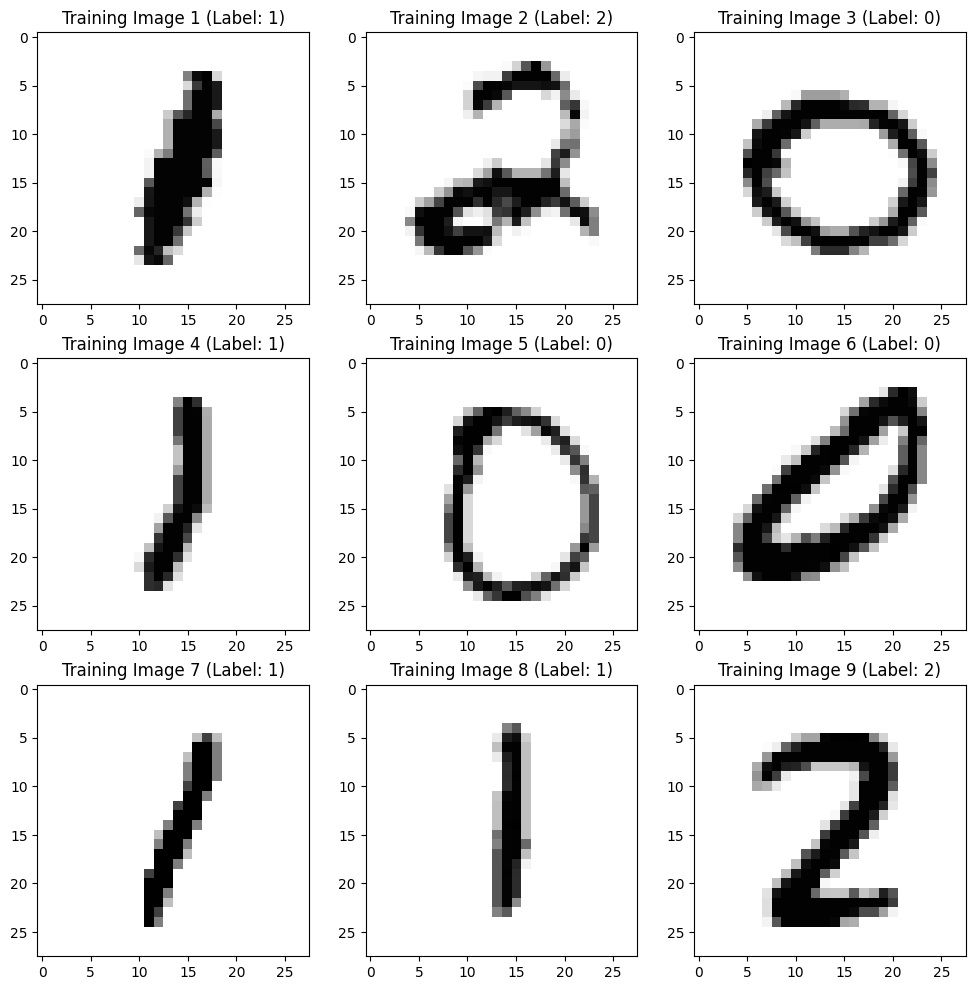

In [82]:
num_rows, num_cols = 3, 3
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(4*num_rows, 4*num_cols))

axes = np.array(axes).reshape(num_rows, num_cols)

for n in range(num_rows):
    for m in range(num_cols):

        ax = axes[n, m]
        image = 1-training_inputs[3*n+m].squeeze().clamp(0,1)

        im = ax.imshow(image, cmap="gray")

        ax.set_title(f"Training Image {3*n+m+1} (Label: {training_labels[3*n+m]})")

plt.show()

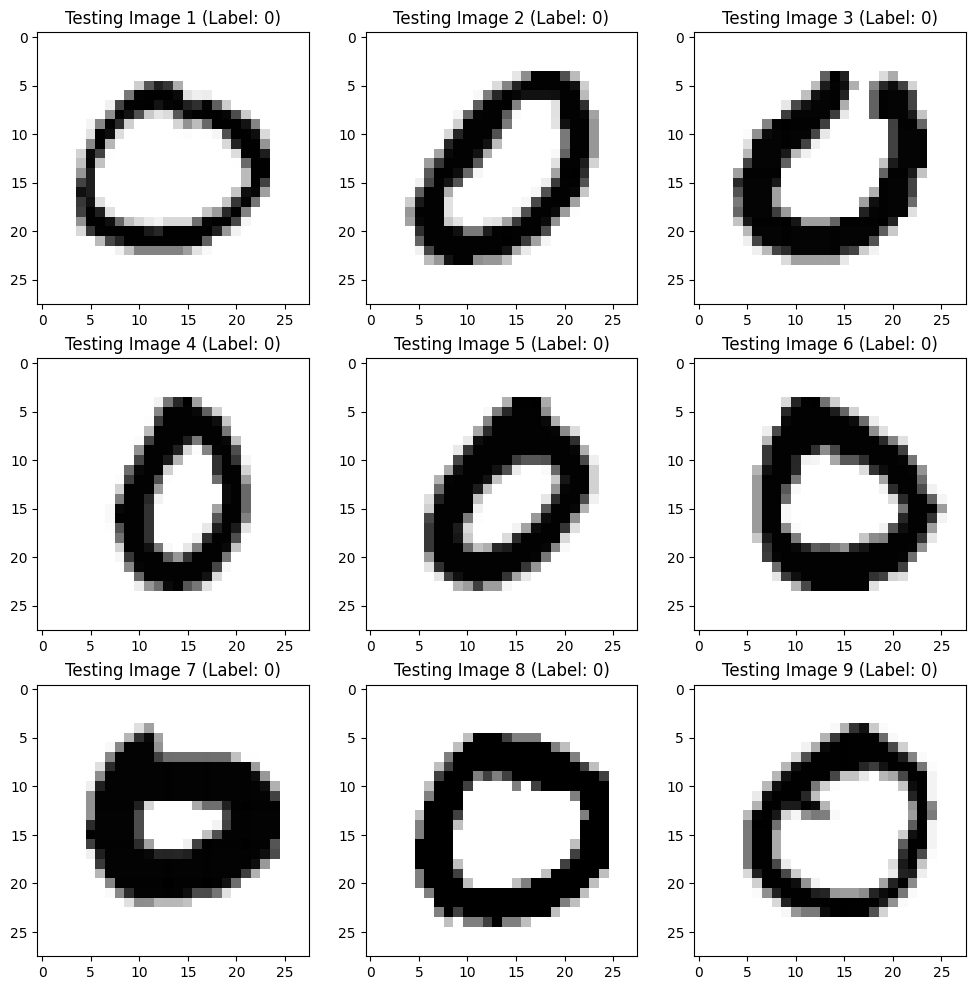

In [83]:
num_rows, num_cols = 3, 3
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(4*num_rows, 4*num_cols))

axes = np.array(axes).reshape(num_rows, num_cols)

for n in range(num_rows):
    for m in range(num_cols):

        ax = axes[n, m]
        image = 1-testing_inputs[3*n+m].squeeze().clamp(0, 1)

        im = ax.imshow(image, cmap="gray")

        ax.set_title(f"Testing Image {3*n+m+1} (Label: {testing_labels[3*n+m]})")

plt.show()

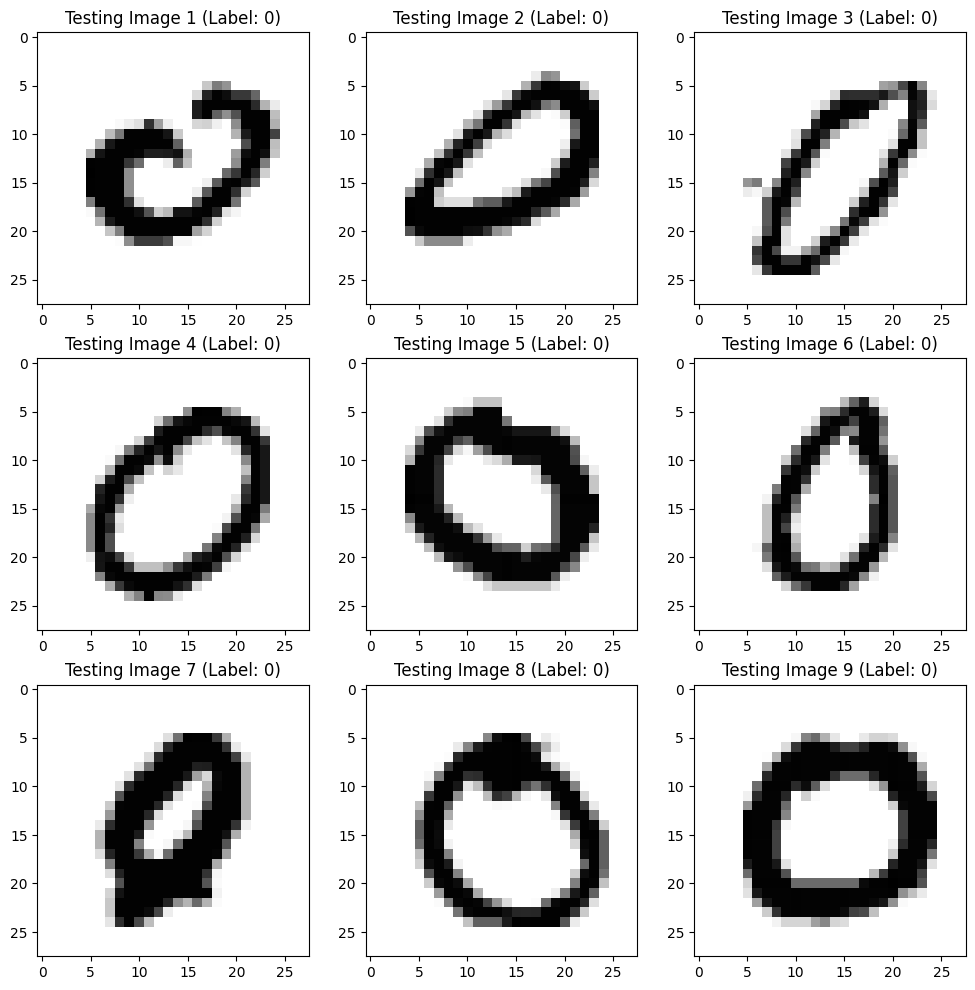

In [84]:
num_rows, num_cols = 3, 3
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(4*num_rows, 4*num_cols))

axes = np.array(axes).reshape(num_rows, num_cols)

for n in range(num_rows):
    for m in range(num_cols):

        ax = axes[n, m]
        image = 1-replay_inputs[3*n+m].squeeze().clamp(0, 1)

        im = ax.imshow(image, cmap="gray")

        ax.set_title(f"Testing Image {3*n+m+1} (Label: {replay_labels[3*n+m]})")

plt.show()

In [38]:
total_num_training_images = 0
num_training_images = []

In [39]:
for i in range(num_training_groups):

    S = 0

    for inputs, labels in training_groups[i]:

        S += len(labels)

    num_training_images.append(S)

    print(f"Number of training images in group {i+1}: {num_training_images[i]}")

    total_num_training_images += S

print()
print(f"Total number of training images: {total_num_training_images}")

Number of training images in group 1: 18623
Number of training images in group 2: 17394

Total number of training images: 36017


In [40]:
total_num_testing_images = 0
num_testing_images = []

In [41]:
for i in range(num_testing_groups):

    S = 0

    for inputs, labels in testing_groups[i]:

        S += len(labels)

    num_testing_images.append(S)

    print(f"Number of testing images of {i}: {num_testing_images[i]}")

    total_num_testing_images += S

print()
print(f"Total number of testing images: {total_num_testing_images}")

Number of testing images of 0: 980
Number of testing images of 1: 1135
Number of testing images of 2: 1032
Number of testing images of 3: 1010
Number of testing images of 4: 982
Number of testing images of 5: 892
Number of testing images of 6: 958
Number of testing images of 7: 1028
Number of testing images of 8: 974
Number of testing images of 9: 1009

Total number of testing images: 10000


In [85]:
total_num_replay_images = 0
num_replay_images = []

In [86]:
for i in range(num_replay_groups):

    S = 0

    for inputs, labels in replay_groups[i]:

        S += len(labels)

    num_replay_images.append(S)

    print(f"Number of replay images of {i}: {num_replay_images[i]}")

    total_num_replay_images += S

print()
print(f"Total number of replay images: {total_num_replay_images}")

Number of replay images of 0: 5923
Number of replay images of 1: 6742
Number of replay images of 2: 5958
Number of replay images of 3: 6131
Number of replay images of 4: 5842
Number of replay images of 5: 5421
Number of replay images of 6: 5918
Number of replay images of 7: 6265
Number of replay images of 8: 5851
Number of replay images of 9: 5949

Total number of replay images: 60000


### Defining NN Architecure

In [42]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.relu = nn.ReLU()

        self.input_size = 28**2
        self.depth1 = 128
        self.depth2 = 64
        self.depth3 = 10

        self.layer1 = nn.Linear(self.input_size, self.depth1)
        self.layer2 = nn.Linear(self.depth1, self.depth2)
        self.layer3 = nn.Linear(self.depth2, self.depth3)
        

    def forward1(self, inputs):

        X = self.flatten(inputs)
        
        X = self.layer1(X)
        X = self.relu(X)

        return X

    def forward2(self, inputs):

        X = self.forward1(inputs)

        X = self.layer2(X)
        X = self.relu(X)

        return X
        

    def forward3(self, inputs):

        X = self.forward2(inputs)

        X = self.layer3(X)

        logits = X

        return logits

    def forward(self, inputs):

        X = self.forward3(inputs)

        logits = X

        return logits


    def hidden(self, inputs):

        hidden = self.forward2(inputs)

        return hidden
        

    def cluster_activation(self, inputs, cluster):

        a1 = self.forward1(inputs)                             # shape: (batch size, num_neurons1)
        a2 = self.forward2(inputs)                             # shape: (batch size, num_neurons2) 
        a3 = self.forward3(inputs)                             # shape: (batch size, num_neurons3)

        all_activations = torch.cat((a1, a2, a3), dim=1)         # shape: (batch size, num_neurons_tot)

        cluster_activation = all_activations[:, cluster].mean(dim = 1)       # shape: (batch size,)

        return cluster_activation
        

### Training 

In [106]:
num_epochs = 5

λ= 100
norm = 2

num_old_pca_components = 16

corr_threshold=0.80
corr_cutoff = 0.20

In [107]:
model = NeuralNetwork()

In [108]:
model_group_set = {}
cm_group_set = {}
pca_group_set = {}
scaler_group_set = {}
varexp_group_set = {}
kmeans_group_set = {}
loss_group_set = {}
linkage_group_set = {}

In [109]:
cumsum_training_digit_groups = []

penalty_function = None

for i in range(num_training_groups):

    model_group_set[i], cm_group_set[i], pca_group_set[i], scaler_group_set[i], varexp_group_set[i], kmeans_group_set[i], loss_group_set[i] = train_model(model, training_data_loader=training_groups[i], training_digit_group=training_digit_groups[i], num_epochs=num_epochs,
                                                                                                                                                            testing_data_loader=testing_groups,
                                                                                                                                                            replay=True, replay_data_loader=replay_groups, replay_digit_group=cumsum_training_digit_groups,
                                                                                                                                                            penalty_function=None, λ=λ
                                                                                                                                                        )


    cumsum_training_digit_groups = cumsum_training_digit_groups+training_digit_groups[i]
    
    #####################################################################################
    ##### PCA DRIFT PENALTY
    #####################################################################################
    #cumsum_training_digit_groups = cumsum_training_digit_groups+training_digit_groups[i]
    #pca, scaler, varexp = get_pca(model_group_set[i], testing_groups, cumsum_training_digit_groups)
    #pca_components = pca.components_[:num_old_pca_components]
    #penalty_function = partial(pca_drift_penalty, old_pca_components = pca_components, old_scaler=scaler, norm=norm)

    #####################################################################################
    ##### CORRS PENALTY
    #####################################################################################
    #cluster_labels, cluster_corrs, linkage_group_set[i] = get_clusters(model_group_set[i], testing_groups, cumsum_training_digit_groups, corr_threshold=corr_threshold) 
    #penalty_function = partial(corrs_penalty, cluster_labels=cluster_labels, cluster_corrs=cluster_corrs, old_model=model_group_set[i], norm=norm, corr_cutoff=corr_cutoff)


    #####################################################################################
    ##### LOGIT PENALTY
    #####################################################################################
    #cumsum_training_digit_groups = cumsum_training_digit_groups+training_digit_groups[i]
    #all_representatives = get_representatives(model_group_set[i], testing_groups, cumsum_training_digit_groups)
    #all_representatives = torch.tensor(all_representatives, dtype=torch.float32)
    #print(all_representatives.shape)
    #penalty_function = partial(logit_penalty, old_model=model_group_set[i], old_representatives=all_representatives, norm=norm)

100%|██████████| 5/5 [01:06<00:00, 13.36s/it, Total Loss=3.8502]


In [110]:
for i in range(num_training_groups):

    print(model_group_set[i] is model)

False
False


### Confusion Matrix

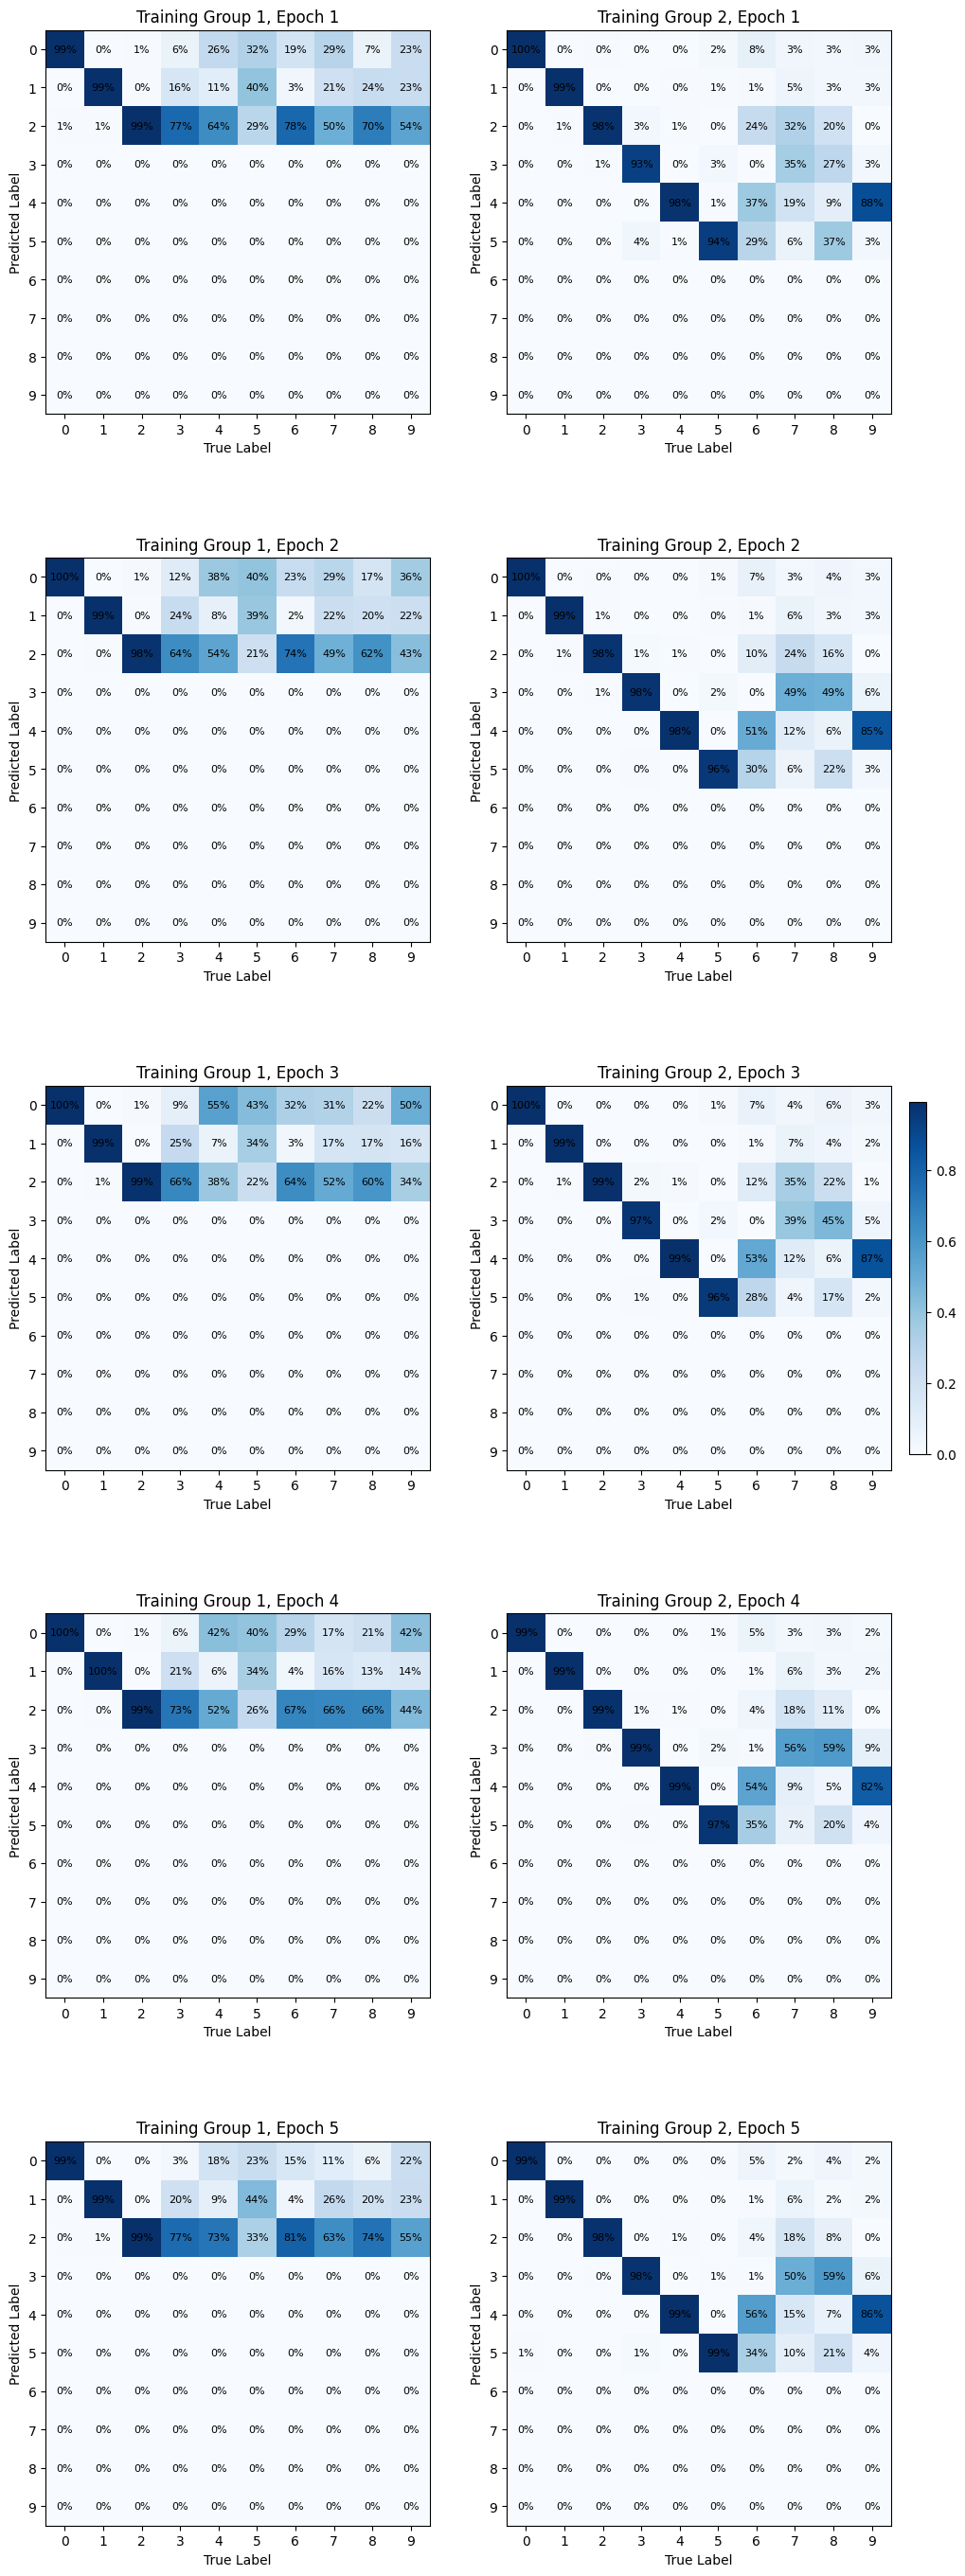

In [111]:
plot_cms(cm_group_set, normalize=True)

### Penultimate Layer PCA

In [112]:
μ_cgm, σ_cgm = monte_carlo_cgm(dim_subspace=1, dim_space=64, n_samples=100_000, seed=42)

In [113]:
μ_cgm, σ_cgm

(0.09930267499286188, 0.07446991020776277)

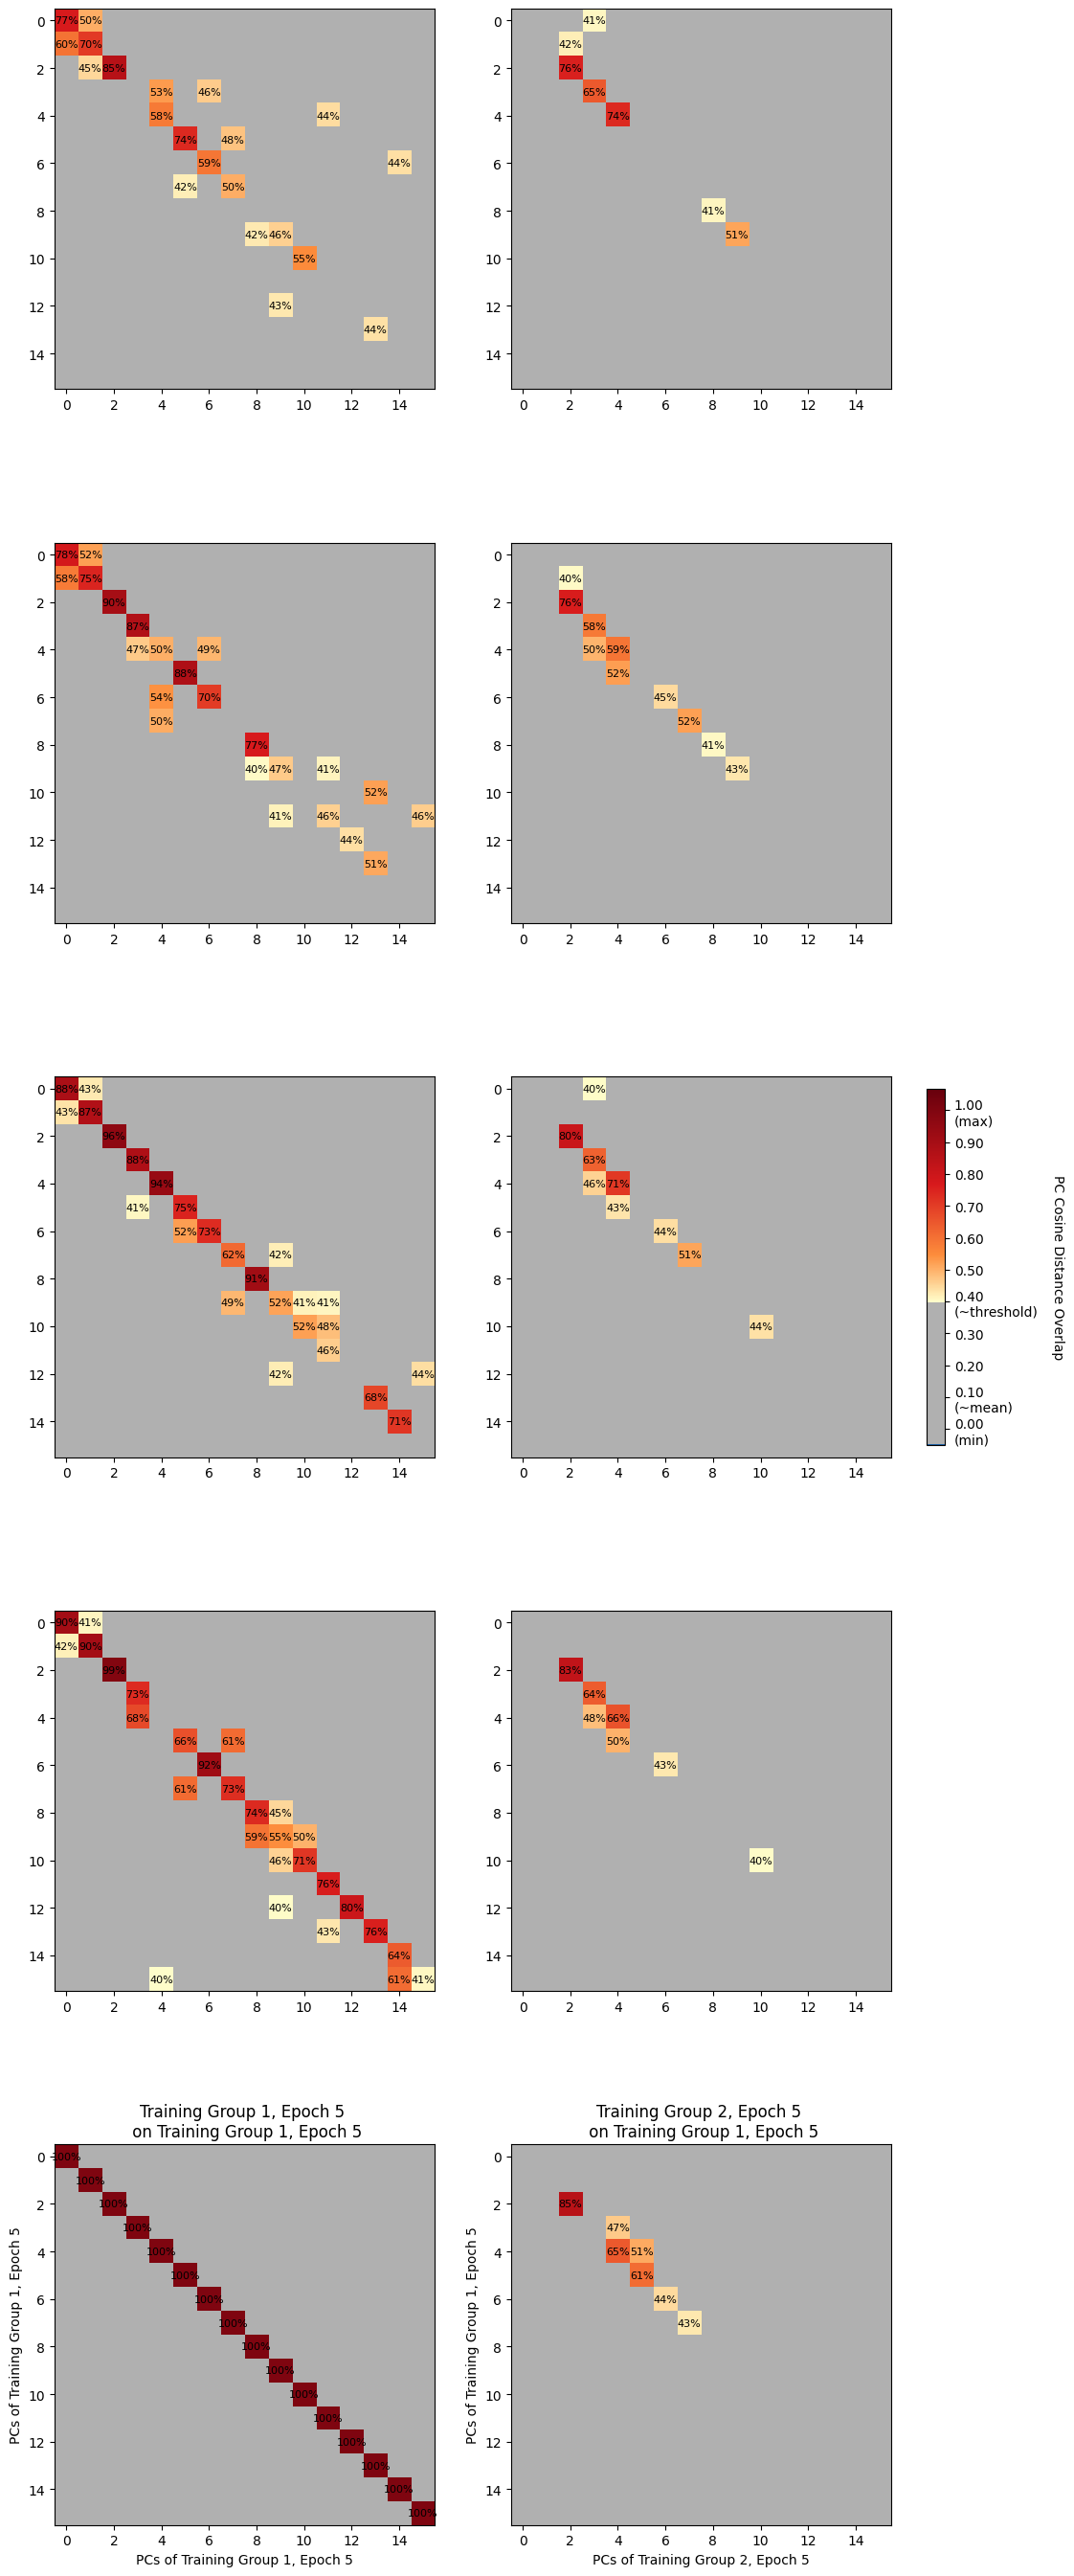

In [114]:
plot_cgms(pca_group_set, μ_cgm, σ_cgm, window=(0, num_old_pca_components), diagonalize=True)

### PCA Variance Explained

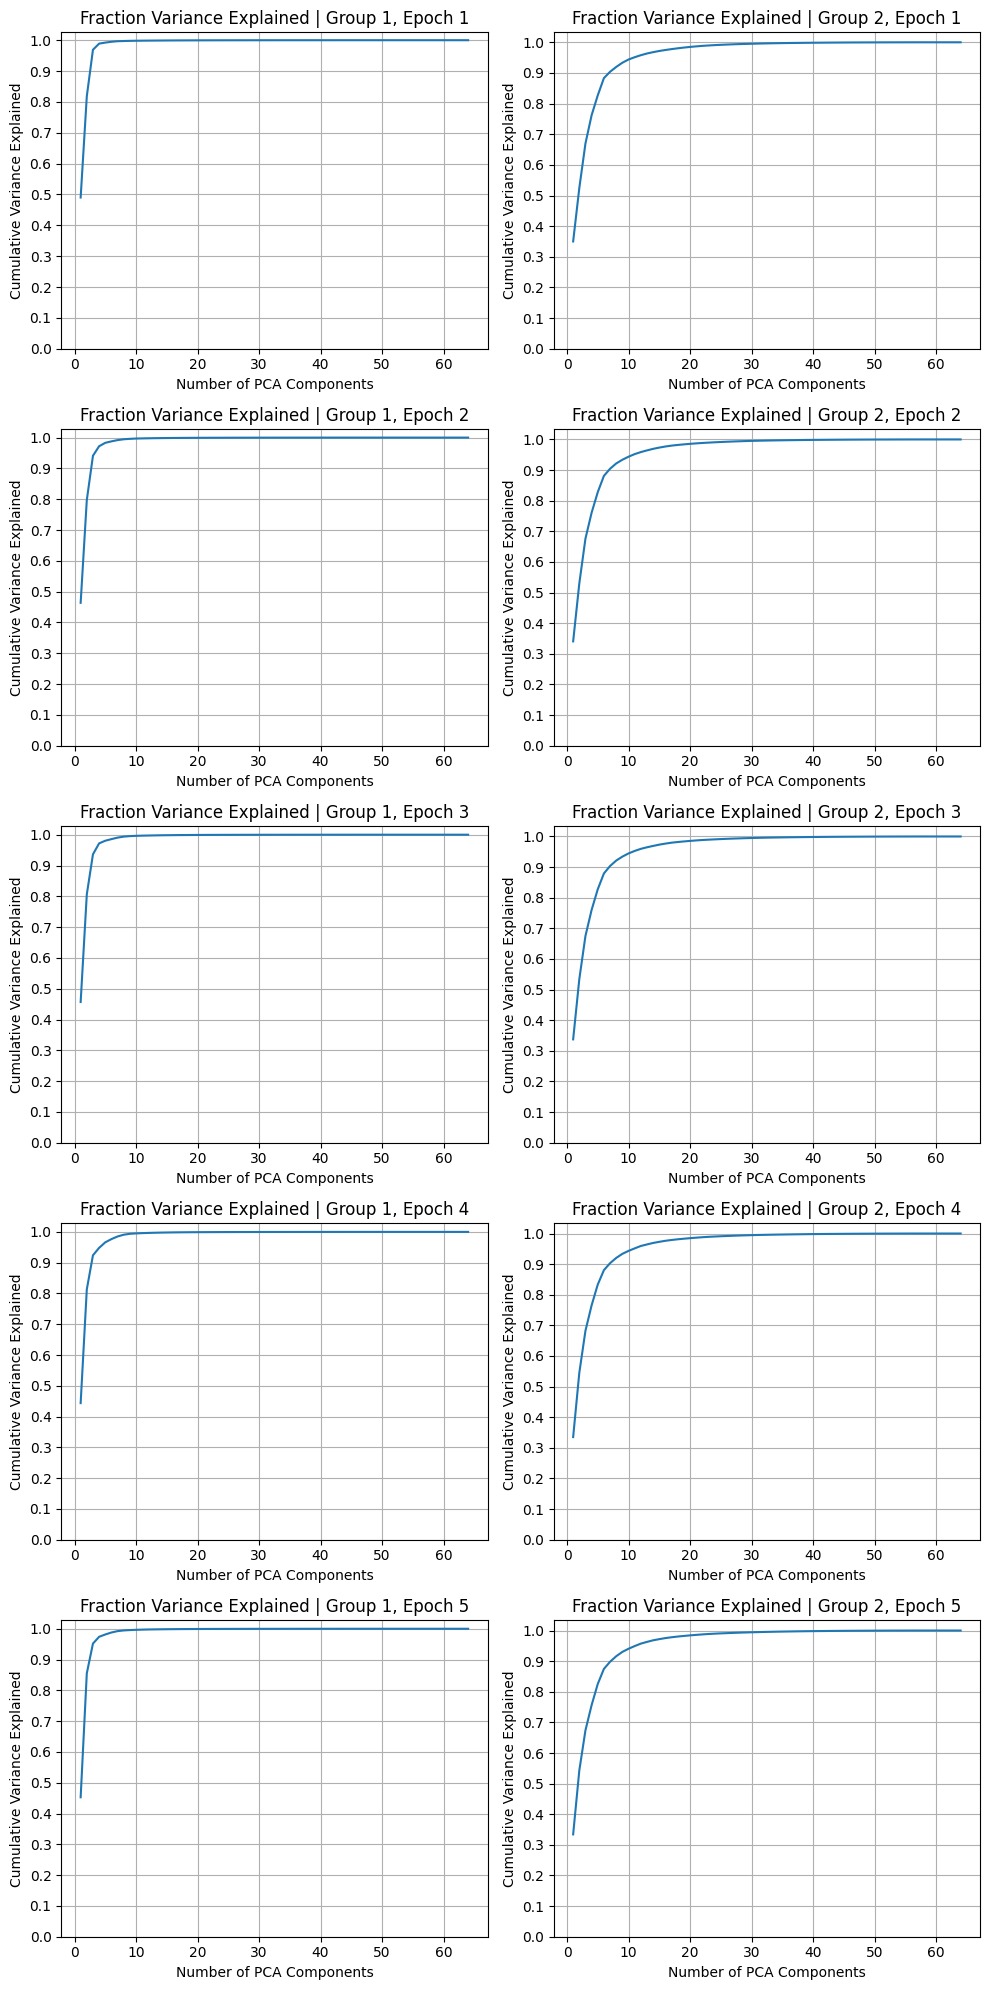

In [115]:
plot_varexp(varexp_group_set)

### k-Means of Hidden Representations

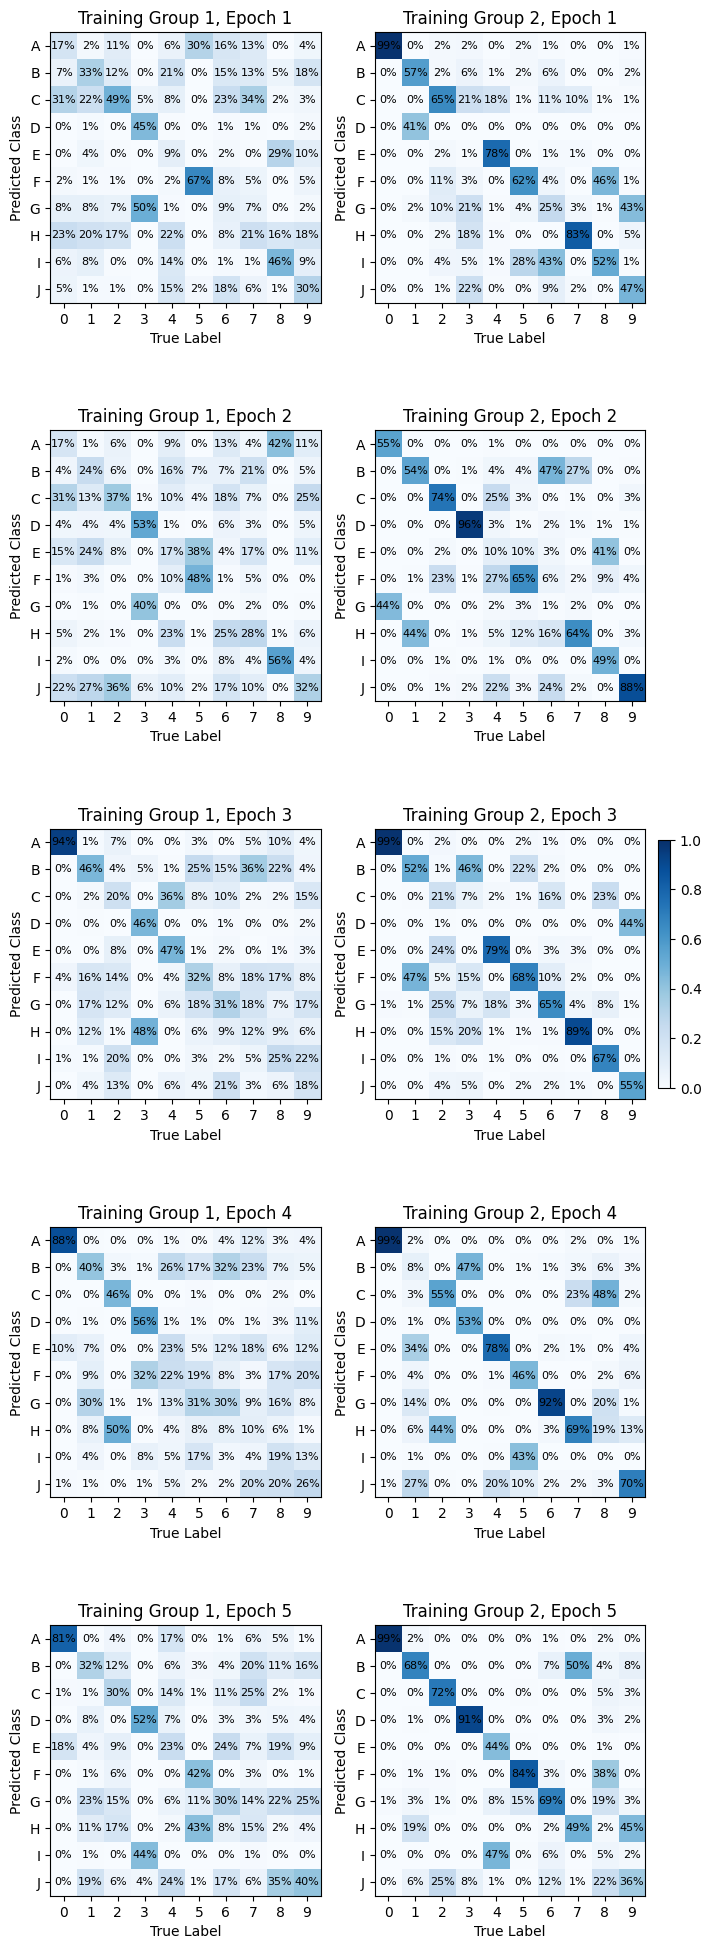

In [116]:
plot_kmeans(kmeans_group_set, diagonalize=True, normalize=True)

### Plotting Training Loss Curves

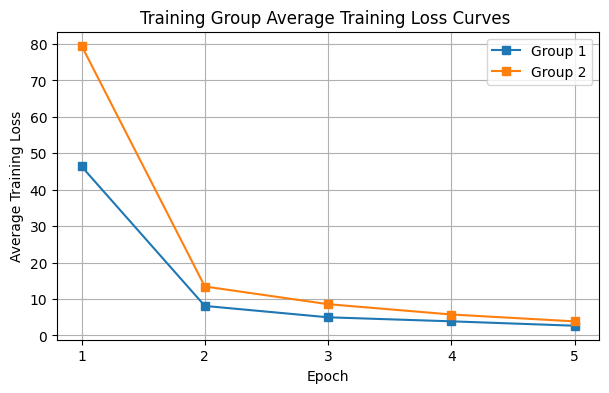

In [117]:
plot_loss(loss_group_set)

### Accuracy Matrix

In [118]:
am = get_am(cm_group_set, training_digit_groups)

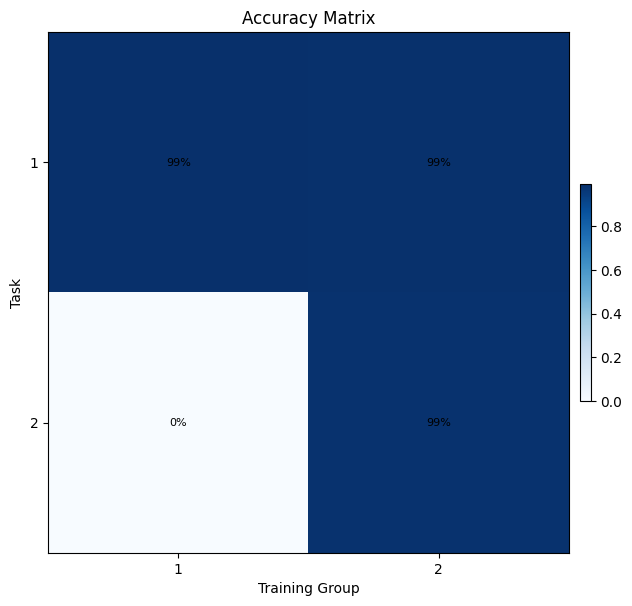

In [119]:
plot_am(am)

### Cluster Graphs

In [73]:
plot_clusters(linkage_group_set)

ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x400 with 0 Axes>

### Control Plot

In [ ]:
rng = np.random.default_rng(seed=SEED)
 
U = rng.standard_normal((64, 64)) 
V = rng.standard_normal((64, 64))        

U, _ = np.linalg.qr(U)                                                   
V, _ = np.linalg.qr(V)                                                   

cgm = np.abs(np.einsum("di, dj -> ij", U, V))        

c_cgm = (cgm - μ_cgm)/σ_cgm

In [ ]:
U.shape, V.shape

In [ ]:
cgm_cmap, cgm_norm = make_colormap(
                                            vmin=-2,
                                            vmax=12,
                                            neutral_low=-2,     
                                            neutral_high=4,
                                            mid1 = 6,
                                            mid2 = 9
                                        )
 
CGM_TICKS  = [-2, -1.3,         0,              2,        4,        6,        9,       12]
CGM_LABELS = ['-2', '-1.3\n(min)', '0\n(mean)', '2', '4', '6', '9', '12']

fig = plt.figure()

im = plt.imshow(c_cgm, cmap=cgm_cmap, norm=cgm_norm)
cbar = plt.colorbar(im, ticks=CGM_TICKS, fraction=0.05, pad=0.04)
cbar.ax.set_yticklabels(CGM_LABELS)
cbar.set_label("PC overlap (σ above baseline)", rotation=270, labelpad=20)

plt.title(f"Control Z-Scored Cross-Gram-Matrix")
plt.xlabel(f"Random Set A of 64 64-Dimensional Unit Vectors")
plt.ylabel(f"Random Set B of 64 64-Dimensional Unit Vectors")

plt.show()